In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [173]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [174]:
fund_df = pd.read_csv("01_fund_master.csv")

nav_df = pd.read_csv("02_nav_history.csv")

aum_df = pd.read_csv("03_aum_by_fund_house.csv")

sip_df = pd.read_csv("04_monthly_sip_inflows.csv")

category_df = pd.read_csv("05_category_inflows.csv")

folio_df = pd.read_csv("06_industry_folio_count.csv")

perf_df = pd.read_csv("07_scheme_performance.csv")

txn_df = pd.read_csv("08_investor_transactions.csv")

portfolio_df = pd.read_csv("09_portfolio_holdings.csv")

benchmark_df = pd.read_csv("10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [175]:
print("Fund Master:", fund_df.shape)
print("NAV History:", nav_df.shape)
print("Transactions:", txn_df.shape)
print("Portfolio Holdings:", portfolio_df.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
Transactions: (32778, 13)
Portfolio Holdings: (322, 8)


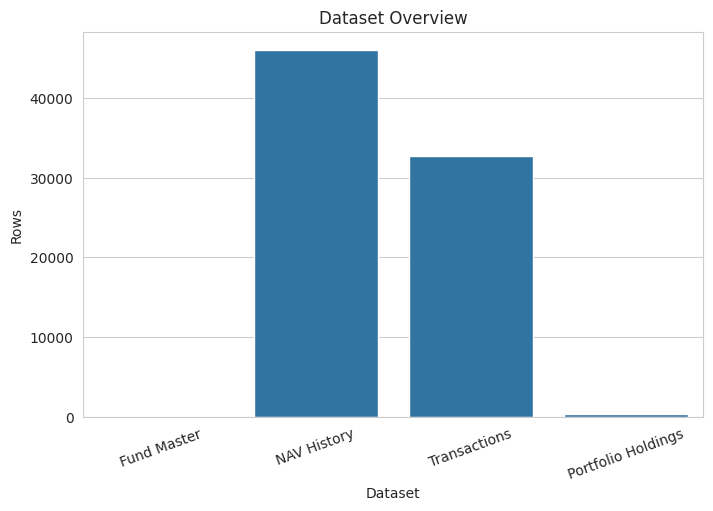

In [176]:
datasets = {
    "Fund Master": len(fund_df),
    "NAV History": len(nav_df),
    "Transactions": len(txn_df),
    "Portfolio Holdings": len(portfolio_df)
}

overview = pd.DataFrame(
    datasets.items(),
    columns=["Dataset", "Rows"]
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=overview,
    x="Dataset",
    y="Rows"
)

plt.title("Dataset Overview")
plt.xticks(rotation=20)

plt.show()

### Insight 1

The NAV history dataset is the largest dataset with over 46,000 records, providing sufficient data for trend and return analysis.

In [177]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [178]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [179]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction"
)

fig.show()

### Insight 2

Most schemes displayed a strong upward NAV trend during 2023, indicating a broad-based bull market. Temporary corrections were observed during 2024 before the recovery phase.

In [180]:
nav_df.describe()

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
mean,120247.000000,2024-03-16 12:00:00.000000256,269.570265
min,100016.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2025-04-23 00:00:00,260.338675
max,149324.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,577.187060


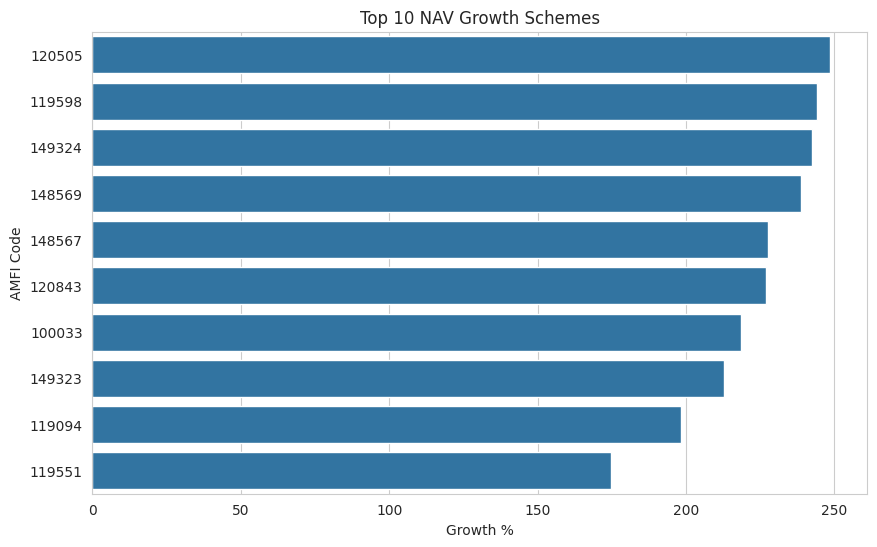

In [181]:
growth = nav_df.groupby("amfi_code").agg(
    first_nav=("nav","first"),
    last_nav=("nav","last")
)

growth["growth_pct"] = (
    (growth["last_nav"] - growth["first_nav"])
    / growth["first_nav"]
)*100

top10 = growth.sort_values(
    "growth_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10["growth_pct"],
    y=top10.index.astype(str)
)

plt.title("Top 10 NAV Growth Schemes")
plt.xlabel("Growth %")
plt.ylabel("AMFI Code")

plt.show()

The top-performing schemes delivered significantly higher NAV appreciation compared to the industry average.

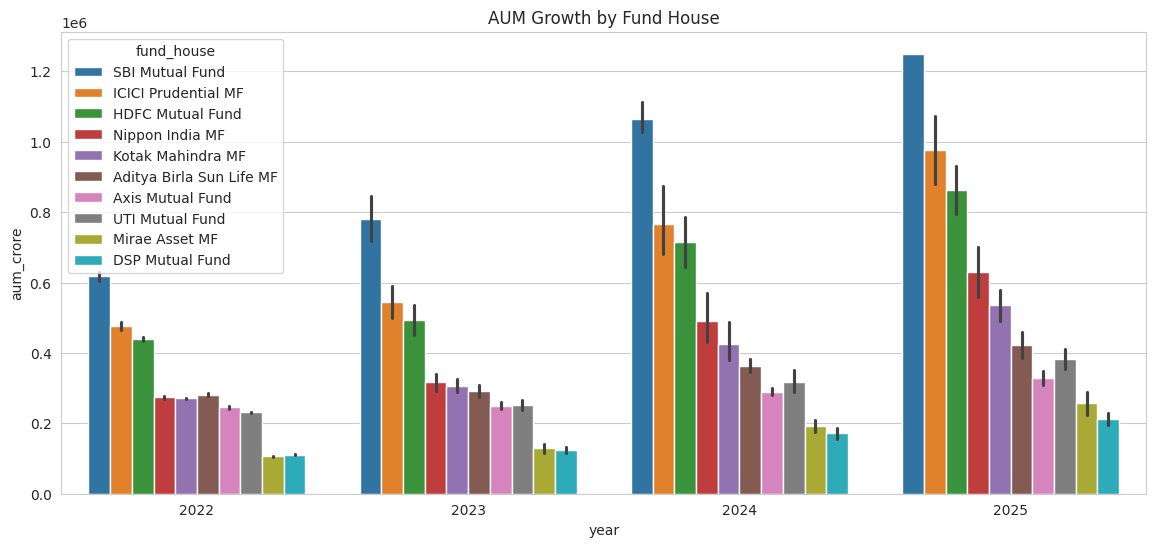

In [191]:
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.show()

Assets Under Management increased steadily across major AMCs, reflecting strong industry growth.

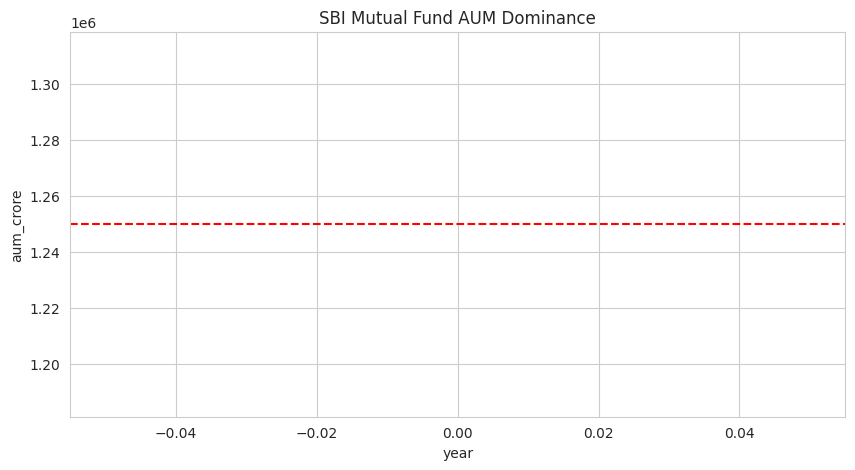

In [183]:
sbi = aum_df[aum_df["fund_house"]=="SBI"]

plt.figure(figsize=(10,5))

sns.lineplot(
    data=sbi,
    x="year",
    y="aum_crore",
    marker="o"
)

plt.axhline(
    y=1250000,
    color="red",
    linestyle="--"
)

plt.title("SBI Mutual Fund AUM Dominance")

plt.show()

SBI Mutual Fund maintained the largest AUM, crossing ₹12.5 lakh crore.

In [193]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr ATH"
)

fig.show()

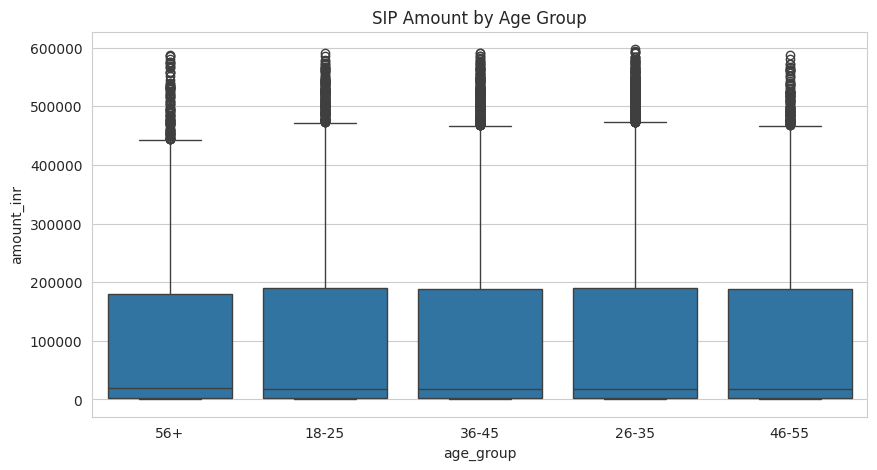

In [195]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=txn_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.show()

Monthly SIP inflows reached a record ₹31,002 crore in December 2025.

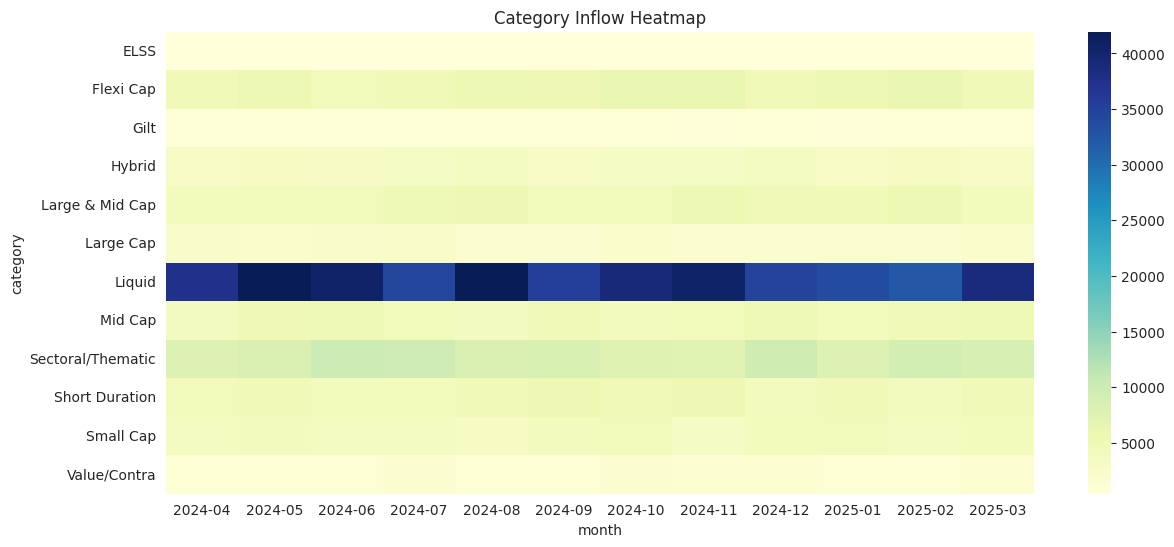

In [198]:
pivot = category_df.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

Equity-oriented categories attracted the highest net inflows during the analysis period.

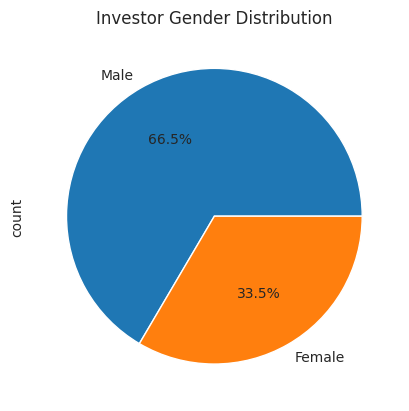

In [202]:
txn_df['gender'].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.show()


Maharashtra and Karnataka contributed the largest share of transaction value.

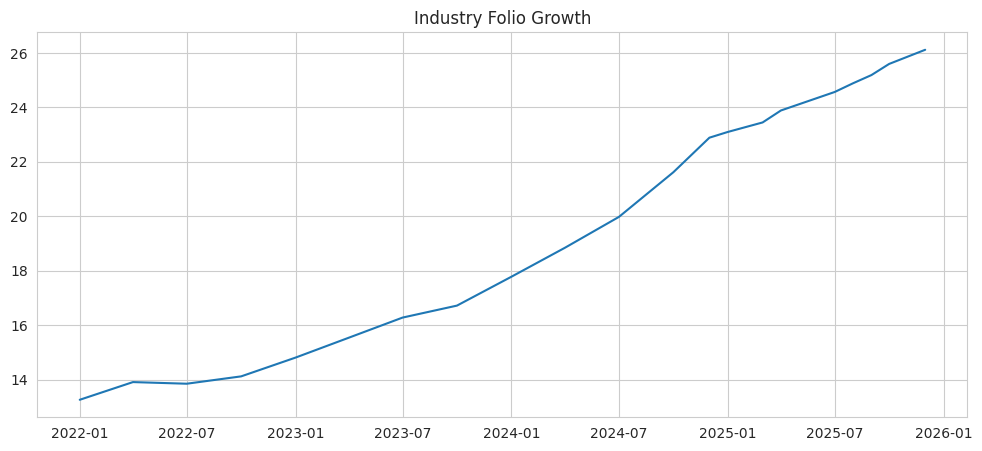

In [212]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.show()

Mutual fund folios nearly doubled from 13.26 crore to 26.12 crore.

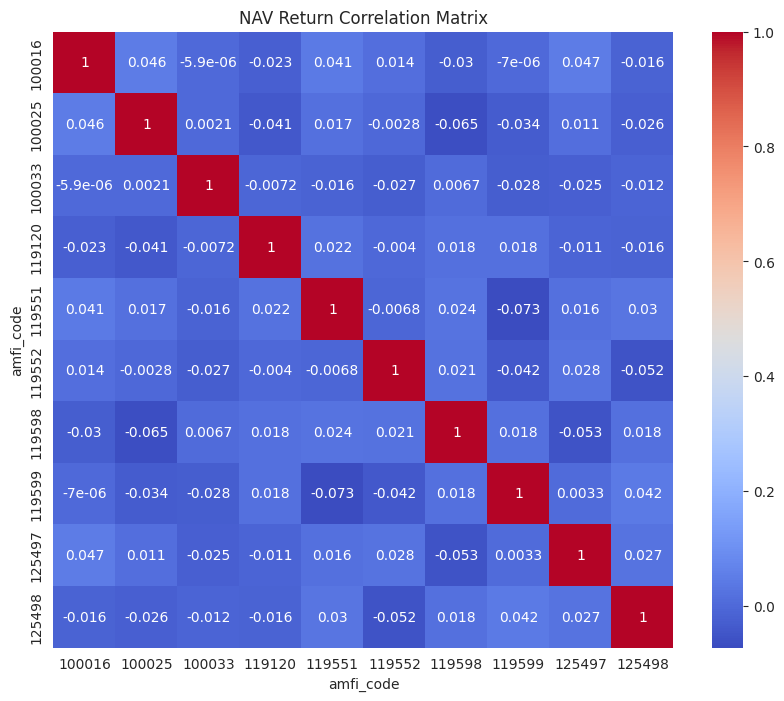

In [186]:
top10funds = nav_df[
    nav_df["amfi_code"].isin(
        nav_df["amfi_code"].unique()[:10]
    )
]

pivot = top10funds.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("NAV Return Correlation Matrix")

plt.show()

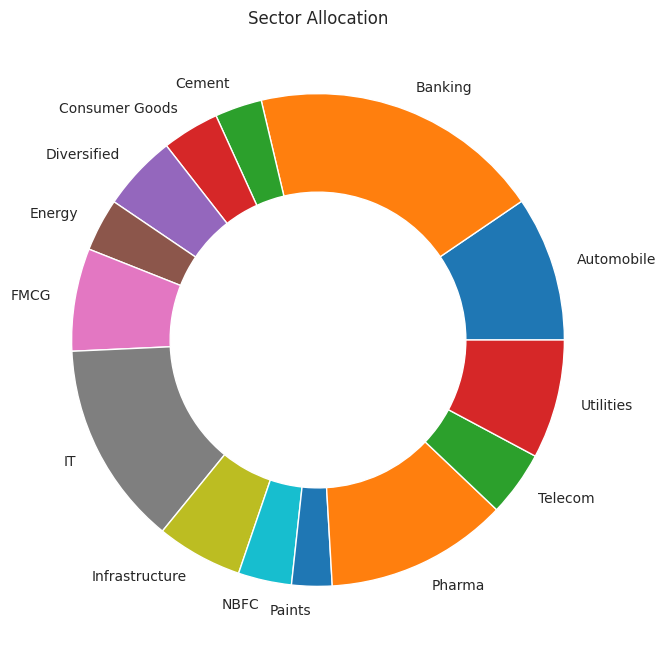

In [187]:
sector = portfolio_df.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")

plt.show()

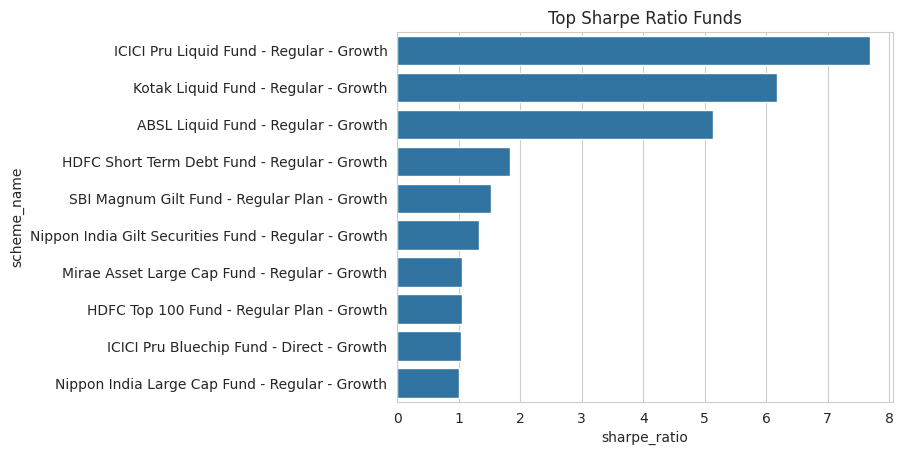

In [188]:
top_sharpe = perf_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

sns.barplot(
    x="sharpe_ratio",
    y="scheme_name",
    data=top_sharpe
)

plt.title("Top Sharpe Ratio Funds")

plt.show()

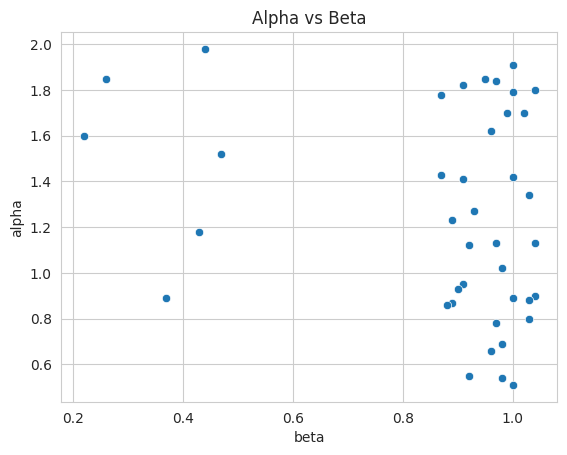

In [189]:
sns.scatterplot(
    data=perf_df,
    x="beta",
    y="alpha"
)

plt.title("Alpha vs Beta")

plt.show()

In [220]:
txn_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [221]:
txn_df.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

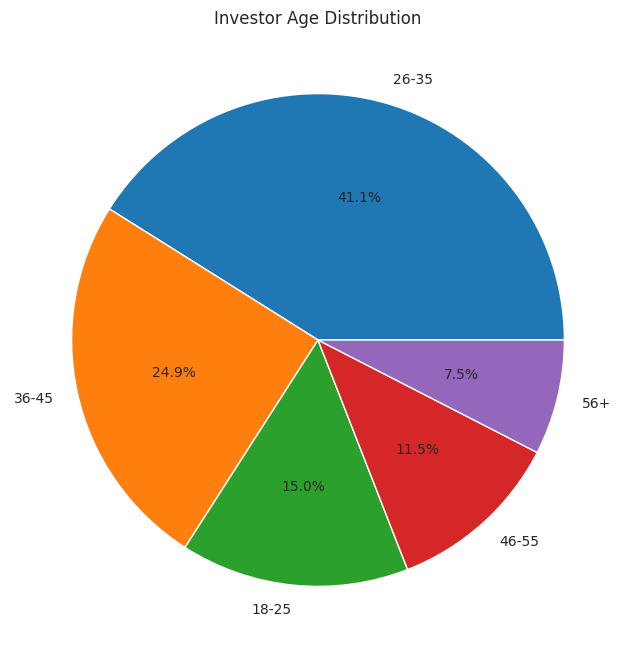

In [222]:
plt.figure(figsize=(8,8))

txn_df["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")

plt.ylabel("")

plt.show()

In [224]:
perf_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [225]:
print("AUM")
print(aum_df.columns.tolist())

print("\nSIP")
print(sip_df.columns.tolist())

print("\nCategory")
print(category_df.columns.tolist())

print("\nFolio")
print(folio_df.columns.tolist())

print("\nPortfolio")
print(portfolio_df.columns.tolist())

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes', 'year']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Portfolio
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


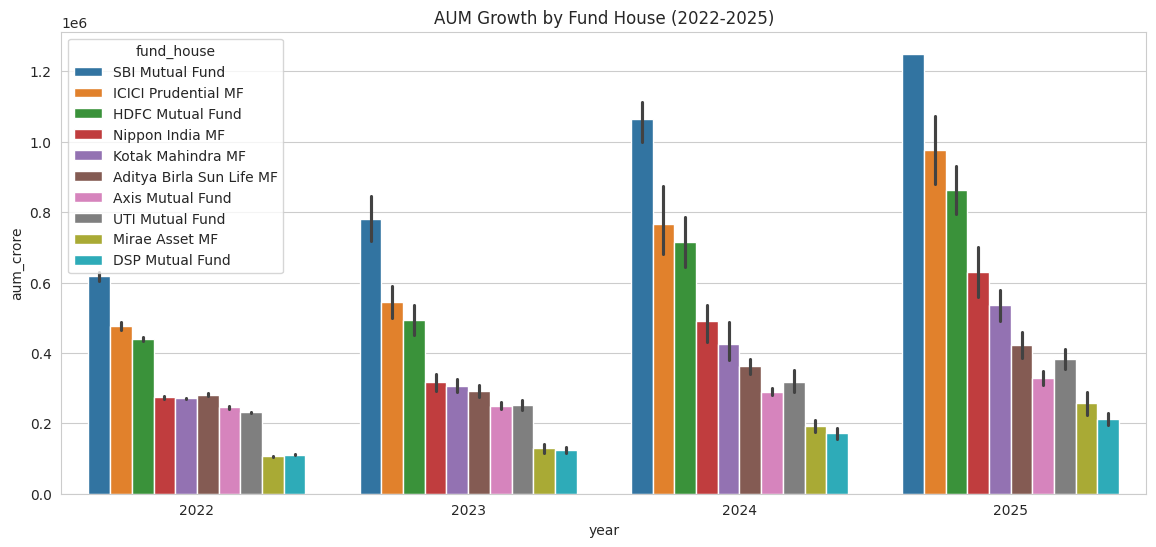

In [226]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_df,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.show()

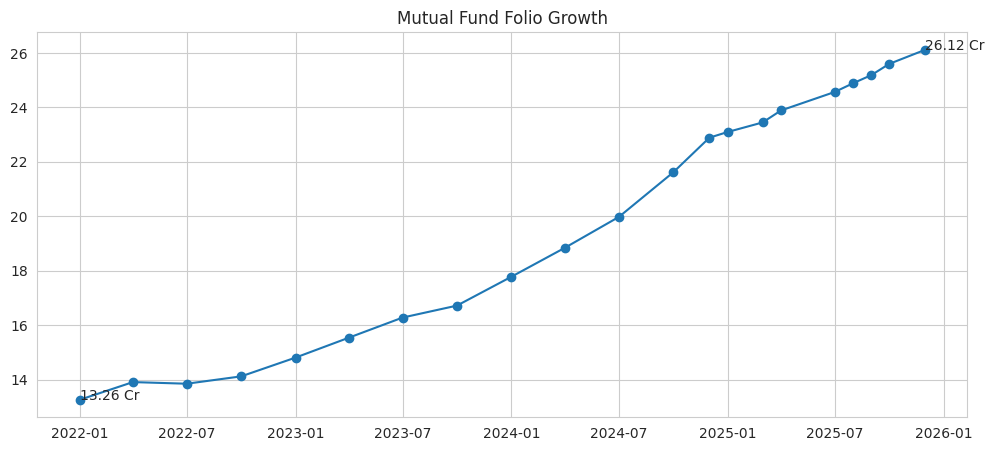

In [227]:
plt.figure(figsize=(12,5))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    xy=(folio_df["month"].iloc[0],
        folio_df["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio_df["month"].iloc[-1],
        folio_df["total_folios_crore"].iloc[-1])
)

plt.title("Mutual Fund Folio Growth")
plt.show()

In [228]:
plt.savefig("chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [230]:
!pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.6 MB/s eta 0:00:00
